<a href="https://colab.research.google.com/github/elijkon/DeepLearningContestModel/blob/main/DeepLearningContest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
How to Run

1.  **Environment Setup:** This project was developed in Google Colab. The first cell of the notebook (`Mrs&MrMeower.ipynb`) contains the necessary `pip` command to install all dependencies.

2.  **Mount Google Drive:** The script requires access to Google Drive to save model checkpoints. You will be prompted to authorize this when running the notebook.

3.  **Execute All Cells:** To run the complete training and evaluation pipeline, select "Run all" from the "Runtime" menu in Google Colab. The script will:
    * Train the VAE.
    * Train the Flow Model.
    * Package the trained models into the `SubmissionInterface`.
    * Run a final test to generate and display 10 sample images.



Model Architecture

### VAE Component
Our VAE is a **Convolutional Neural Network**. We chose a CNN architecture because it is highly effective at capturing the spatial features of image data, leading to better quality reconstructions compared to a simple MLP. The encoder uses `Conv2d` layers to downsample the image, while the decoder uses `ConvTranspose2d` layers to upsample the latent vector back into an image. We use `SiLU` as our activation function for its smooth, non-monotonic properties.

### Flow Model Component
The flow model is a simple **Multi-Layer Perceptron (MLP)**. Its role is to learn the vector field of the VAE's latent space, which is a relatively low-dimensional task. An MLP provides sufficient capacity for this purpose while keeping the parameter count low.


## Training Strategy

Our training used several key techniques to ensure stability and high-quality results:

* KL Annealing: We use a linear warm-up schedule for the KL divergence term in the VAE loss. This starts the KL weight at zero and slowly ramps it up, allowing the model to learn good reconstructions before being regularized. This was crucial for preventing mode collapse.
* KL Vanishing Fix: We discovered our model was learning to "cheat" by setting the latent variance to zero. We fixed this by applying a `tanh` constraint to the `log_var` output in the VAE's forward pass, forcing the model to learn a meaningful variance.
* Learning Rate Scheduler: We use a `ReduceLROnPlateau` scheduler to automatically lower the learning rate if the VAE's training loss stalls, helping the optimizer escape local minima.
* Gradient Clipping: We clip the gradients during VAE training to a maximum norm of 1.0 to prevent exploding gradients and ensure numerical stability.

'''

'\nHow to Run\n\n1.  **Environment Setup:** This project was developed in Google Colab. The first cell of the notebook (`Mrs&MrMeower.ipynb`) contains the necessary `pip` command to install all dependencies.\n\n2.  **Mount Google Drive:** The script requires access to Google Drive to save model checkpoints. You will be prompted to authorize this when running the notebook.\n\n3.  **Execute All Cells:** To run the complete training and evaluation pipeline, select "Run all" from the "Runtime" menu in Google Colab. The script will:\n    * Train the VAE.\n    * Train the Flow Model.\n    * Package the trained models into the `SubmissionInterface`.\n    * Run a final test to generate and display 10 sample images.\n\n\n\nModel Architecture\n\n### VAE Component\nOur VAE is a **Convolutional Neural Network**. We chose a CNN architecture because it is highly effective at capturing the spatial features of image data, leading to better quality reconstructions compared to a simple MLP. The encoder 

In [ ]:
# Authors: Elijah Konkle and Evan Dant
# Date: 2025-10-12
# Description: An end-to-end latent flow matching system for generating MNIST digits.
# This script trains a Convolutional VAE to learn a compressed latent space and then
# trains a flow model to generate new samples within that space.

# --- 0. Environment Setup ---
!pip install torch torchvision safetensors matplotlib wandb -q

# --- 1. Essential Imports and Setup ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from safetensors.torch import save_file, load_file
import matplotlib.pyplot as plt
import os
import wandb

# Set the device to GPU (cuda) if available, otherwise CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Connect to Google Drive for saving model checkpoints
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Login to Weights & Biases for experiment tracking
wandb.login()

# Start a new run and define your hyperparameters
config = {
    "learning_rate_vae": 5e-4,
    "learning_rate_flow": 1e-4,
    "epochs_vae": 100,
    "epochs_flow": 100,
    "latent_dim": 12,
    "batch_size": 128,
    "kl_beta_target": 0.001,
    "kl_warmup_epochs": 15 }

# Initialize a new W&B run to track this experiment
wandb.init(
    project="latent-flow-matching",
    config=config
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


vae/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
vae/kl_beta,▁▁▂▂▃▃▄▅▅▆▆▇▇███████████████████████████
vae/kl_loss,▇█▆▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
vae/recon_loss,█▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
vae/total_loss,█▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
vae/epoch,45
vae/kl_beta,0.001
vae/kl_loss,3.65448
vae/recon_loss,0.09418
vae/total_loss,0.09784


In [ ]:
# class SimpleVAEModel(nn.Module):

#     def __init__(self, latent_dim=3, n_hid=[256,64], act=nn.LeakyReLU):
#         super().__init__()
#         self.encoder = nn.Sequential(
#             nn.Linear(28 * 28, n_hid[0]), act(),
#             nn.Linear(n_hid[0], n_hid[1]), act(),
#             nn.Linear(n_hid[1], latent_dim * 2),
#         )
#         self.decoder = nn.Sequential(
#             nn.Linear(latent_dim, n_hid[1]), act(),
#             nn.Linear(n_hid[1], n_hid[0]), act(),
#             nn.Linear(n_hid[0], 28 * 28),
#             nn.Sigmoid(),
#         )
#         self.latent_dim = latent_dim

#     def reparam_sample(self, mu, log_var):
#         std = torch.exp(0.5 * log_var)
#         noise = torch.randn_like(std)
#         return mu + std * noise

#     def forward(self, x):
#         x = x.view(x.size(0), -1)
#         z_params = self.encoder(x)
#         i_half = z_params.shape[-1] // 2
#         mu, log_var = z_params[:, :i_half], z_params[:, i_half:]
#         z_hat = self.reparam_sample(mu, log_var)
#         x_hat = self.decoder(z_hat)
#         return x_hat, mu, log_var

# Helper module to handle reshaping within an nn.Sequential block
class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)

class ConvolutionalVAE(nn.Module):
    """
    A Convolutional Variational Autoencoder (VAE) for MNIST.
    This model uses convolutional layers to learn an efficient, low-dimensional
    representation (latent space) of the 28x28 digit images.
    """
    def __init__(self, latent_dim=12, base_channels=32):
        super().__init__()
        self.latent_dim = latent_dim

        #encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Flatten(),
        )


        self.fc_latent = nn.Linear(base_channels * 2 * 7 * 7, latent_dim * 2)

        #decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 2 * 7 * 7),
            Reshape(-1, base_channels * 2, 7, 7),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.ConvTranspose2d(base_channels, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def reparam_sample(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        noise = torch.randn_like(std)
        return mu + std * noise


    def forward(self, x):
        # Encode
        h = self.encoder_conv(x)
        latent_params = self.fc_latent(h)
        mu, log_var_raw = latent_params.chunk(2, dim=-1)

        # Apply the tanh constraint
        log_var = torch.tanh(log_var_raw) * 4.0



        # Sample latent vector
        z = self.reparam_sample(mu, log_var)

        # Decode
        x_hat = self.decoder(z)

        return x_hat, mu, log_var

class SimpleFlowModel(nn.Module):
    """
    A simple MLP-based flow model that learns a vector field in the latent space.
    Its goal is to transform a simple Gaussian distribution into the complex
    distribution of the VAE's latent vectors.
    """
    def __init__(self, latent_dim=3, n_hidden=64, n_layers=3, act=nn.LeakyReLU):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(latent_dim + 1, n_hidden), act(),
            *[nn.Sequential(nn.Linear(n_hidden, n_hidden), act()) for _ in range(n_layers - 1)],
            nn.Linear(n_hidden, latent_dim),
        )

    def forward(self, x, t):
        t = t.expand(x.size(0), 1)
        xt = torch.cat([x, t], dim=1)
        return self.layers(xt)

In [ ]:
# --- 4. Data Loading ---
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)

In [ ]:
# --- 5. VAE Training ---
print("--- Training VAE ---")
vae = ConvolutionalVAE(latent_dim=config['latent_dim']).to(device)
optimizer = optim.AdamW(vae.parameters(), lr=config["learning_rate_vae"])

# Scheduler to reduce the learning rate if the loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5) # Wait 5 epochs with no improvement before reducing LR

def vae_loss_fn(x, x_hat, mu, log_var, beta):
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    #KL Annealing cause collapsing
    rescaled_kl_loss = kl_loss * beta
    return recon_loss + rescaled_kl_loss, recon_loss, kl_loss

# VAE training loop
for epoch in range(config["epochs_vae"]):
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    # Calculate the current KL weight for this epoch using a linear warm-up schedule
    current_beta = min(config["kl_beta_target"] * (epoch / config["kl_warmup_epochs"]), config["kl_beta_target"])

    for data, _ in train_loader:
        data = data.to(device)
        x_hat, mu, log_var = vae(data)
        loss, recon_loss, kl_loss = vae_loss_fn(data, x_hat, mu, log_var, current_beta)
        optimizer.zero_grad()
        loss.backward()
        # Clip gradients to a max norm of 1.0 to prevent exploding gradients and stabilize training
        torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
        optimizer.step()

        # Accumulate losses for logging
        epoch_total_loss += loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_kl_loss += kl_loss.item()


    avg_total_loss = epoch_total_loss / len(train_loader)
    avg_recon_loss = epoch_recon_loss / len(train_loader)
    avg_kl_loss = epoch_kl_loss / len(train_loader)
    wandb.log({
        "vae/epoch": epoch,
        "vae/total_loss": avg_total_loss,
        "vae/recon_loss": avg_recon_loss,
        "vae/kl_loss": avg_kl_loss
    })
    print(f"VAE Epoch {epoch+1}, Total Loss: {avg_total_loss:.4f}")
    scheduler.step(avg_total_loss)

    # --- WANDB: Log reconstruction images at the end of each epoch ---
    with torch.no_grad():
        vae.eval()
        # Get a few original images
        originals = data[:8].cpu()
        # Get their reconstructions
        reconstructions, _, _ = vae(originals.to(device))
        reconstructions = reconstructions.cpu().view(-1, 1, 28, 28)

        original_images = [wandb.Image(img) for img in originals]
        recon_images = [wandb.Image(img) for img in reconstructions]
        # Convert to numpy and remove the channel dimension for wandb
        wandb.log({"vae/originals": original_images,
                   "vae/reconstructions": recon_images,
                   "vae/kl_beta": current_beta
        }) # Convert to numpy and remove channel
        vae.train()

save_file(vae.state_dict(), "vae_weights.safetensors2")
print("VAE model weights saved to vae_weights.safetensors2")

--- Training VAE ---
VAE Epoch 1, Total Loss: 0.1911
VAE Epoch 2, Total Loss: 0.1262
VAE Epoch 3, Total Loss: 0.1170
VAE Epoch 4, Total Loss: 0.1125
VAE Epoch 5, Total Loss: 0.1098
VAE Epoch 6, Total Loss: 0.1079
VAE Epoch 7, Total Loss: 0.1066
VAE Epoch 8, Total Loss: 0.1055
VAE Epoch 9, Total Loss: 0.1047
VAE Epoch 10, Total Loss: 0.1041
VAE Epoch 11, Total Loss: 0.1036
VAE Epoch 12, Total Loss: 0.1032
VAE Epoch 13, Total Loss: 0.1029
VAE Epoch 14, Total Loss: 0.1027
VAE Epoch 15, Total Loss: 0.1025
VAE Epoch 16, Total Loss: 0.1023
VAE Epoch 17, Total Loss: 0.1020
VAE Epoch 18, Total Loss: 0.1016
VAE Epoch 19, Total Loss: 0.1013
VAE Epoch 20, Total Loss: 0.1011
VAE Epoch 21, Total Loss: 0.1008
VAE Epoch 22, Total Loss: 0.1006
VAE Epoch 23, Total Loss: 0.1004
VAE Epoch 24, Total Loss: 0.1002
VAE Epoch 25, Total Loss: 0.1000
VAE Epoch 26, Total Loss: 0.0998
VAE Epoch 27, Total Loss: 0.0997
VAE Epoch 28, Total Loss: 0.0995
VAE Epoch 29, Total Loss: 0.0994
VAE Epoch 30, Total Loss: 0.099

In [ ]:
# --- 6. Flow Model Training ---
print("\n--- Training Flow Model ---")

vae.eval()
all_latents = []
with torch.no_grad():
    for data, _ in train_loader:
        data = data.to(device)
        _ , mu, _ = vae(data)
        all_latents.append(mu)
latents_dataset = TensorDataset(torch.cat(all_latents, dim=0))
latents_loader = DataLoader(latents_dataset, batch_size=256, shuffle=True)

def flow_matching_loss(model, x1):
    x0 = torch.randn_like(x1)

    t = torch.rand(x1.size(0), 1, device=x1.device)

    xt = (1 - t) * x0 + t * x1

    ut = x1 - x0

    vt = model(xt, t).squeeze()
    return F.mse_loss(vt, ut)

flow_model = SimpleFlowModel(latent_dim=config['latent_dim']).to(device)
optimizer = optim.Adam(flow_model.parameters(), config['learning_rate_flow'])

#flow model training
for epoch in range(config["epochs_flow"]):
    total_loss = 0
    for batch in latents_loader:
        x1 = batch[0].to(device)
        loss = flow_matching_loss(flow_model, x1)
        optimizer.zero_grad()
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(latents_loader)
    wandb.log({
        "flow/epoch": epoch,
        "flow/loss": avg_loss
    })
    print(f"Flow Model Epoch {epoch+1}, Loss: {avg_loss:.4f}")

save_file(flow_model.state_dict(), "flow_weights.safetensors2")
print("Flow model weights saved to flow_weights.safetensors")
wandb.finish()


--- Training Flow Model ---
Flow Model Epoch 1, Loss: 4.9313
Flow Model Epoch 2, Loss: 4.1623
Flow Model Epoch 3, Loss: 3.7769
Flow Model Epoch 4, Loss: 3.6177
Flow Model Epoch 5, Loss: 3.5297
Flow Model Epoch 6, Loss: 3.4988
Flow Model Epoch 7, Loss: 3.4676
Flow Model Epoch 8, Loss: 3.4456
Flow Model Epoch 9, Loss: 3.4443
Flow Model Epoch 10, Loss: 3.4280
Flow Model Epoch 11, Loss: 3.4180
Flow Model Epoch 12, Loss: 3.4144
Flow Model Epoch 13, Loss: 3.4189
Flow Model Epoch 14, Loss: 3.3704
Flow Model Epoch 15, Loss: 3.3797
Flow Model Epoch 16, Loss: 3.3576
Flow Model Epoch 17, Loss: 3.3467
Flow Model Epoch 18, Loss: 3.3387
Flow Model Epoch 19, Loss: 3.3313
Flow Model Epoch 20, Loss: 3.3325
Flow Model Epoch 21, Loss: 3.3295
Flow Model Epoch 22, Loss: 3.3273
Flow Model Epoch 23, Loss: 3.3139
Flow Model Epoch 24, Loss: 3.2975
Flow Model Epoch 25, Loss: 3.2946
Flow Model Epoch 26, Loss: 3.2678
Flow Model Epoch 27, Loss: 3.2864
Flow Model Epoch 28, Loss: 3.2660
Flow Model Epoch 29, Loss: 3

flow/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇██
flow/loss,██▇▇▇▆▆▆▆▅▅▄▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
vae/epoch,▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
vae/kl_beta,▁▂▆▆▇███████████████████████████████████
vae/kl_loss,█▆▄▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
vae/recon_loss,█▇▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
vae/total_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
flow/epoch,99
flow/loss,2.9609
vae/epoch,99
vae/kl_beta,0.001



--- Integrating and Testing SubmissionInterface ---


Downloading...
From: https://drive.google.com/uc?id=1zOq7bPDDuO-a77Zi-g6nvbxARI4hXNTf
To: /content/downloaded_vae.safetensors
100%|██████████| 732k/732k [00:00<00:00, 139MB/s]


Loaded VAE weights into SubmissionInterface.


Downloading...
From: https://drive.google.com/uc?id=1y_jSgUGIMWI-L5Hf1d9Jw1EuyTVSiZgy
To: /content/downloaded_flow.safetensors
100%|██████████| 40.6k/40.6k [00:00<00:00, 58.6MB/s]

Loaded Flow Model weights into SubmissionInterface.


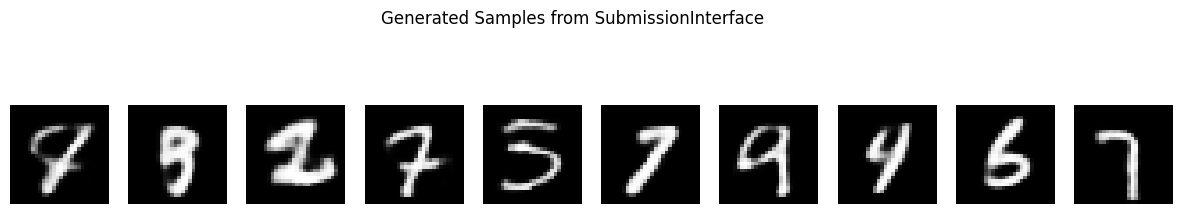

In [ ]:
import gdown
# --- 7. Final SubmissionInterface and Generation ---
print("\n--- Integrating and Testing SubmissionInterface ---")

# Sampling and Integration Functions
@torch.no_grad()
def fwd_euler_step(model, current_points, current_t, dt):
    velocity = model(current_points, current_t)
    return current_points + velocity * dt

@torch.no_grad()
def integrate_path(model, initial_points, n_steps=100):
    current_points = initial_points.clone()
    ts = torch.linspace(0, 1, n_steps).to(initial_points.device)
    for i in range(len(ts) - 1):
        dt = ts[i+1] - ts[i]
        current_points = fwd_euler_step(model, current_points, ts[i], dt)
    return current_points

class SubmissionInterface(nn.Module):
    """The final class for automated evaluation, loading the trained models."""
    def __init__(self):
        super().__init__()
        self.info = {
            'team': 'spooky skeletons', # Replace with your team name
            'names': 'Elijah Konkle and Evan Dant', # Replace with your names
        }
        self.latent_dim = 12
        self.load_vae()
        self.load_flow_model()
        self.device = 'cpu'

    def load_vae(self):
        """
        Loads the VAE weights from a Google Drive link.
        PASTE YOUR LINK HERE FOR FINAL SUBMISSION.
        """
        self.vae = ConvolutionalVAE(latent_dim=self.latent_dim)
        vae_weights_file = 'downloaded_vae.safetensors'
        # --- PASTE YOUR VAE LINK HERE ---
        safetensors_link = "https://drive.google.com/file/d/1zOq7bPDDuO-a77Zi-g6nvbxARI4hXNTf/view?usp=sharing"

        if "PASTE" in safetensors_link:
            print("WARNING: VAE link is a placeholder. Please update it for submission.")
            # For testing, we'll try to load the local file instead.
            self.vae.load_state_dict(load_file("vae_weights.safetensors2"))
        else:
            gdown.download(safetensors_link, vae_weights_file, quiet=False, fuzzy=True)
            self.vae.load_state_dict(load_file(vae_weights_file))
        print("Loaded VAE weights into SubmissionInterface.")


    def load_flow_model(self):
        """
        Loads the flow model weights from a Google Drive link.
        PASTE YOUR LINK HERE FOR FINAL SUBMISSION.
        """
        self.flow_model = SimpleFlowModel(latent_dim=self.latent_dim)
        flow_weights_file = 'downloaded_flow.safetensors'
        # --- PASTE YOUR FLOW MODEL LINK HERE ---
        safetensors_link = "https://drive.google.com/file/d/1y_jSgUGIMWI-L5Hf1d9Jw1EuyTVSiZgy/view?usp=sharing"

        if "PASTE" in safetensors_link:
            print("WARNING: Flow Model link is a placeholder. Please update it for submission.")
            # For testing, we'll try to load the local file instead.
            self.flow_model.load_state_dict(load_file("flow_weights.safetensors"))
        else:
            gdown.download(safetensors_link, flow_weights_file, quiet=False, fuzzy=True)
            self.flow_model.load_state_dict(load_file(flow_weights_file))
        print("Loaded Flow Model weights into SubmissionInterface.")

    # ... (generate_samples, encode, decode, to methods remain the same)
    def generate_samples(self, n_samples: int, n_steps=100) -> torch.Tensor:
        self.flow_model.eval()
        z0 = torch.randn([n_samples, self.latent_dim]).to(self.device)
        z1 = integrate_path(self.flow_model, z0, n_steps=n_steps)
        gen_xhat = self.decode(z1).view(-1, 28, 28)
        return gen_xhat

    def encode(self, images: torch.Tensor) -> torch.Tensor:
        self.vae.eval()
        with torch.no_grad():
            _, mu, _ = self.vae(images.to(self.device))
            return mu

    def decode(self, latents: torch.Tensor) -> torch.Tensor:
        self.vae.eval()
        with torch.no_grad():
            return self.vae.decoder(latents.to(self.device))

    def to(self, device):
        self.device = device
        self.vae.to(self.device)
        self.flow_model.to(self.device)
        return self

# --- Final Usage and Visualization ---
# This will now test the interface by loading the local files as a fallback
mysub = SubmissionInterface().to(device)
generated_samples = mysub.generate_samples(n_samples=10)

fig, axes = plt.subplots(1, 10, figsize=(15, 3))
fig.suptitle("Generated Samples from SubmissionInterface")
for i, ax in enumerate(axes):
    ax.imshow(generated_samples[i].cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.show()
